<a href="https://colab.research.google.com/github/kshero18/Research_Project_Code/blob/main/PPO_Simulation%2C_real_world_data_and_old_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install dependencies
!pip install pandas openpyxl stable-baselines3 gymnasium matplotlib

import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [3]:
!pip install simpy

In [4]:
import numpy as np
import simpy
import pandas as pd

# Define parameters
lambda_1 = 4  # Arrival rate for primary questions (customers per minute)
lambda_2 = 2  # Arrival rate for complex questions (customers per minute)
mu_1 = 3      # Service rate for less experienced agent (customers per minute)
mu_2 = 4      # Service rate for more experienced agent (customers per minute)
M = 5         # Maximum number of calls in the system
T = 40        # Simulation time threshold for accepting new customers
simulation_end_time = 60  # Total simulation time
dt = 0.6

overtime_cost_rate = 1  # Overtime cost rate per minute beyond threshold (agent working overtime)

# Precomputing the value function V using DPL
V = np.full((int(T/dt) + 1, M + 1, M + 1, 2), np.inf)
V[:, 0, 0, :] = 0  # Initial condition: no waiting cost when there are no customers

for t in range(1, int(T/dt) + 1):
    for q1 in range(M + 1):
        for q2 in range(M + 1):
            if q1 + q2 > M:
                continue
            cost_rep1 = (q1 + 1) / mu_1 + q2 / mu_2 if q1 + 1 <= M else np.inf  # Expected cost if assigned to rep 1
            cost_rep2 = q1 / mu_1 + (q2 + 1) / mu_2 if q2 + 1 <= M else np.inf  # Expected cost if assigned to rep 2
            V[t, q1, q2, 0] = min(cost_rep1, cost_rep2)

class CallCenter:
    def __init__(self, env, dt, V, use_longest_waiting=True):
        self.env = env
        self.V = V
        self.dt = dt
        self.use_longest_waiting = use_longest_waiting
        self.queue_1 = simpy.Store(env)  # Queue for primary questions
        self.queue_2 = simpy.Store(env)  # Queue for complex questions
        self.agent_1 = simpy.Resource(env, capacity=1)
        self.agent_2 = simpy.Resource(env, capacity=1)
        self.total_waiting_time = 0
        self.total_agent_overtime_cost = 0  # Track only agent overtime costs
        self.total_rewards = 0  # Track total rewards
        self.customers_served = 0
        self.customers_rejected = 0  # Track customers rejected after T = 40
        self.transition_counts = {}  # Track state transitions
        self.state_counts = {}  # Count visits to states

    def record_transition(self, current_state, next_state):
        """Records state transitions for computing probabilities."""
        self.transition_counts[(current_state, next_state)] = (
            self.transition_counts.get((current_state, next_state), 0) + 1
        )
        self.state_counts[current_state] = self.state_counts.get(current_state, 0) + 1

    def calculate_transition_probabilities(self):
        """Calculates transition probabilities from recorded transitions."""
        probabilities = {}
        for (current_state, next_state), count in self.transition_counts.items():
            total_transitions_from_state = self.state_counts[current_state]
            probabilities[(current_state, next_state)] = count / total_transitions_from_state
        return probabilities

    def handle_customer(self, customer_type, agent, service_rate, arrival_time, state):
        with (self.agent_1 if agent == "Agent 1" else self.agent_2).request() as request:
            yield request
            service_time = np.random.exponential(1 / service_rate)
            end_time = self.env.now + service_time  # Calculate when the service will end

            # Simulate the service time
            yield self.env.timeout(service_time)

            wait_time = self.env.now - arrival_time  # Calculate wait time
            self.total_waiting_time += wait_time

            # Initialize agent_overtime_cost to zero
            agent_overtime_cost = 0

            # Check for overtime due to working beyond T
            if end_time > T:
                overtime_hours = end_time - T
                agent_overtime_cost = overtime_hours * overtime_cost_rate
                self.total_agent_overtime_cost += agent_overtime_cost

            # Update rewards
            reward = -(wait_time + agent_overtime_cost)  # Negative rewards for wait time and overtime
            self.total_rewards += reward

            self.customers_served += 1

            next_state = (len(self.queue_1.items), len(self.queue_2.items))

            # Record the state transition
            self.record_transition(state, next_state)

            # Log details
            print(
                f"At time {self.env.now:.2f}: Customer type {customer_type} served by {agent} "
                f"in {service_time:.2f} minutes, waited {wait_time:.2f} minutes "
                f"(Overtime cost: {agent_overtime_cost:.2f}, Reward: {reward:.2f})"
            )
            print(f"    Transition: State {state} -> State {next_state}")

    def assign_customer(self):
        while True:
            if self.agent_1.count == 0 or self.agent_2.count == 0:
                state = (len(self.queue_1.items), len(self.queue_2.items))

                # Select action based on policy
                chosen_agent = self.policy.get(state, "Agent 1")
                queue = self.queue_1 if chosen_agent == "Agent 1" else self.queue_2

                if len(queue.items) > 0:
                    customer_type, arrival_time = queue.items[0]
                    yield queue.get()

                    service_rate = mu_1 if chosen_agent == "Agent 1" else mu_2
                    self.env.process(self.handle_customer(customer_type, chosen_agent, service_rate, arrival_time, state))

            yield self.env.timeout(self.dt)

    def assign_customer(self):
        while True:
            if self.agent_1.count == 0 or self.agent_2.count == 0:
                queue, customer_type, arrival_time = self.select_customer()

                if queue is not None:
                    state = (len(self.queue_1.items), len(self.queue_2.items))  # Current state
                    yield queue.get()

                    chosen_agent = "Agent 1" if self.agent_1.count == 0 else "Agent 2"
                    service_rate = mu_1 if chosen_agent == "Agent 1" else mu_2

                    # Start handling the customer
                    self.env.process(self.handle_customer(customer_type, chosen_agent, service_rate, arrival_time, state))

            # Update rewards based on current queue lengths
            queue_penalty = -(len(self.queue_1.items) + len(self.queue_2.items))  # Negative reward for queue lengths
            self.total_rewards += queue_penalty

            yield self.env.timeout(dt)  # Allow other processes to run

    def select_customer(self):
        """Selects the customer based on the queue and waiting strategy."""
        if self.use_longest_waiting:
            return self.select_longest_waiting_customer()
        return self.select_first_come_first_served_customer()

    def select_longest_waiting_customer(self):
        """Select the longest waiting customer from the queues."""
        if len(self.queue_1.items) > 0 and len(self.queue_2.items) > 0:
            customer_1, arrival_time_1 = self.queue_1.items[0]
            customer_2, arrival_time_2 = self.queue_2.items[0]
            if arrival_time_1 <= arrival_time_2:
                return self.queue_1, customer_1, arrival_time_1
            else:
                return self.queue_2, customer_2, arrival_time_2
        elif len(self.queue_1.items) > 0:
            customer_1, arrival_time_1 = self.queue_1.items[0]
            return self.queue_1, customer_1, arrival_time_1
        elif len(self.queue_2.items) > 0:
            customer_2, arrival_time_2 = self.queue_2.items[0]
            return self.queue_2, customer_2, arrival_time_2
        else:
            return None, None, None

    def select_first_come_first_served_customer(self):
        """Select the first customer from queue 1 or queue 2."""
        if len(self.queue_1.items) > 0:
            return self.queue_1, *self.queue_1.items[0]
        elif len(self.queue_2.items) > 0:
            return self.queue_2, *self.queue_2.items[0]
        return None, None, None

    def value_iteration(env, gamma=0.9, iterations=100):
      V = {}
      policy = {}

      # Initialize value function for all states
      for q1 in range(M + 1):
          for q2 in range(M + 1):
              V[(q1, q2)] = 0  # Initial value for all states

      for i in range(iterations):
          new_V = V.copy()
          for q1 in range(M + 1):
              for q2 in range(M + 1):
                  if q1 + q2 > M:  # Invalid state
                      continue

                  # Possible actions: assign to Agent 1 or Agent 2
                  actions = ["Agent 1", "Agent 2"]
                  action_values = []

                  for action in actions:
                      # Immediate reward
                      immediate_cost = -(q1 / mu_1 if action == "Agent 1" else q2 / mu_2)

                      # Future value estimation
                      future_value = 0
                      for next_q1 in range(M + 1):
                          for next_q2 in range(M + 1):
                              if next_q1 + next_q2 > M:  # Invalid state
                                  continue
                              # Transition probability (placeholder: uniform probability)
                              P = 1 / ((M + 1) * (M + 1))  # Example; calculate based on transitions
                              future_value += P * V[(next_q1, next_q2)]

                      action_value = immediate_cost + gamma * future_value
                      action_values.append(action_value)

                  # Update value function and policy
                  new_V[(q1, q2)] = max(action_values)
                  policy[(q1, q2)] = actions[np.argmax(action_values)]

          V = new_V  # Update V for next iteration

      return V, policy

    def customer_arrival(self, customer_type, arrival_rate):
        while True:
            inter_arrival_time = np.random.exponential(1 / arrival_rate)
            yield self.env.timeout(inter_arrival_time)
            arrival_time = self.env.now

            if arrival_time > T:
                self.customers_rejected += 1
                print(f"Customer rejected at time {arrival_time:.2f}: No new arrivals after T = {T}")
                continue

            if customer_type == 1:
                self.queue_1.put((customer_type, arrival_time))
            else:
                self.queue_2.put((customer_type, arrival_time))

            self.env.process(self.assign_customer())


def run_simulation(simulation_time, use_longest_waiting=True):
    env = simpy.Environment()
    call_center = CallCenter(env, dt, V, use_longest_waiting)

    env.process(call_center.customer_arrival(1, lambda_1))
    env.process(call_center.customer_arrival(2, lambda_2))

    env.run(until=simulation_time)

    print(f"\nTotal customers served: {call_center.customers_served}")
    print(f"Total waiting time: {call_center.total_waiting_time:.2f} minutes")
    print(f"Total agent overtime cost: {call_center.total_agent_overtime_cost:.2f} minutes")
    print(f"Total rewards: {call_center.total_rewards:.2f}")
    print(f"Total customers rejected after T = {T}: {call_center.customers_rejected}")
    print(f"Average waiting time per customer: "
          f"{(call_center.total_waiting_time / call_center.customers_served):.2f} minutes")

    # Calculate and display transition probabilities
    probabilities = call_center.calculate_transition_probabilities()
    print("\nTransition Probabilities:")
    for (initial_state, final_state), prob in probabilities.items():
        print(f"  P({final_state} | {initial_state}) = {prob:.4f}")

    return call_center.total_waiting_time, call_center.total_agent_overtime_cost, call_center.customers_served, call_center.total_rewards, call_center.customers_rejected, probabilities


# Run the simulations
simulation_time = simulation_end_time

# With longest waiting customer function
waiting_time_longest, agent_overtime_longest, served_longest, rewards_longest, rejected_longest, probs_longest = run_simulation(simulation_time, use_longest_waiting=True)

# Without longest waiting customer function
waiting_time_fcfs, agent_overtime_fcfs, served_fcfs, rewards_fcfs, rejected_fcfs, probs_fcfs = run_simulation(simulation_time, use_longest_waiting=False)


# Prepare the results for the table
results_data = {
    "Metric": [
        "Total Waiting Time (minutes)",
        "Total Agent Overtime Cost",
        "Total Customers Served",
        "Total Rewards",
        "Total Customers Rejected"
    ],
    "With Longest Waiting": [
        waiting_time_longest,
        agent_overtime_longest,
        served_longest,
        rewards_longest,
        rejected_longest
    ],
    "Without Longest Waiting": [
        waiting_time_fcfs,
        agent_overtime_fcfs,
        served_fcfs,
        rewards_fcfs,
        rejected_fcfs
    ],
    "Difference (Without - With)": [
        waiting_time_fcfs - waiting_time_longest,
        agent_overtime_fcfs - agent_overtime_longest,
        served_fcfs - served_longest,
        rewards_fcfs - rewards_longest,
        rejected_fcfs - rejected_longest
    ]
}

# Create the DataFrame
results_df = pd.DataFrame(results_data)

# Display the results as a table
print(results_df.to_string(index=False))



At time 0.31: Customer type 1 served by Agent 1 in 0.12 minutes, waited 0.12 minutes (Overtime cost: 0.00, Reward: -0.12)
    Transition: State (1, 0) -> State (0, 1)
At time 0.36: Customer type 2 served by Agent 1 in 0.05 minutes, waited 0.16 minutes (Overtime cost: 0.00, Reward: -0.16)
    Transition: State (0, 2) -> State (0, 1)
At time 0.66: Customer type 1 served by Agent 2 in 0.45 minutes, waited 0.45 minutes (Overtime cost: 0.00, Reward: -0.45)
    Transition: State (1, 0) -> State (0, 1)
At time 1.05: Customer type 1 served by Agent 2 in 0.14 minutes, waited 0.14 minutes (Overtime cost: 0.00, Reward: -0.14)
    Transition: State (1, 0) -> State (0, 0)
At time 1.05: Customer type 2 served by Agent 1 in 0.25 minutes, waited 0.73 minutes (Overtime cost: 0.00, Reward: -0.73)
    Transition: State (0, 1) -> State (0, 0)
At time 1.31: Customer type 1 served by Agent 1 in 0.19 minutes, waited 0.19 minutes (Overtime cost: 0.00, Reward: -0.19)
    Transition: State (1, 0) -> State (1, 0

In [5]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3

# ===============================
# 📦 STEP 2: ENVIRONMENT DEFINITION
# ===============================
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from IPython.display import display

class CallCenterPPOEnv(gym.Env):
    def __init__(self):
        super(CallCenterPPOEnv, self).__init__()
        self.lambda_1 = 4
        self.lambda_2 = 2
        self.mu_1 = 3
        self.mu_2 = 4
        self.T = 40
        self.simulation_end_time = 60
        self.dt = 0.6
        self.max_queue_length = 10
        self.overtime_cost_rate = 1

        self.observation_space = spaces.Box(low=np.array([0, 0, 0.0]),
                                            high=np.array([self.max_queue_length, self.max_queue_length, self.simulation_end_time]),
                                            dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queue_1 = []
        self.queue_2 = []
        self.agent_1_busy_until = 0
        self.agent_2_busy_until = 0
        self.now = 0
        self.total_reward = 0
        self.total_waiting_time = 0
        self.total_overtime_cost = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([len(self.queue_1), len(self.queue_2), self.now], dtype=np.float32)

    def step(self, action):
        terminated = False
        truncated = False

        if self.now >= self.simulation_end_time:
            terminated = True
            return self._get_obs(), 0, terminated, truncated, {}

        if np.random.rand() < self.lambda_1 * self.dt:
            self.queue_1.append(self.now)
        if np.random.rand() < self.lambda_2 * self.dt:
            self.queue_2.append(self.now)

        wait_time = 0
        overtime_cost = 0
        if action == 0 and self.queue_1:
            arrival_time = self.queue_1.pop(0)
            wait_time = self.now - arrival_time
            service_time = np.random.exponential(1 / self.mu_1)
            end_time = self.now + service_time
            if end_time > self.T:
                overtime_cost = (end_time - self.T) * self.overtime_cost_rate
            self.agent_1_busy_until = end_time
        elif action == 1 and self.queue_2:
            arrival_time = self.queue_2.pop(0)
            wait_time = self.now - arrival_time
            service_time = np.random.exponential(1 / self.mu_2)
            end_time = self.now + service_time
            if end_time > self.T:
                overtime_cost = (end_time - self.T) * self.overtime_cost_rate
            self.agent_2_busy_until = end_time

        # Slightly reduce queue penalty to make PPO more effective
        reward = -(wait_time + overtime_cost + 0.5 * (len(self.queue_1) + len(self.queue_2)))
        self.total_reward += reward
        self.total_waiting_time += wait_time
        self.total_overtime_cost += overtime_cost

        self.now += self.dt
        return self._get_obs(), reward, terminated, truncated, {}

# ===============================
# ✅ STEP 3: CHECK ENVIRONMENT
# ===============================
env = CallCenterPPOEnv()
check_env(env)

# ===============================
# 🧠 STEP 4: TRAIN PPO AGENT
# ===============================
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=50000)

# ===============================
# 📊 STEP 5: EVALUATE PPO AGENT
# ===============================
def evaluate_ppo(model, env, episodes=10):
    rewards, waits, overtimes = [], [], []
    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        rewards.append(env.total_reward)
        waits.append(env.total_waiting_time)
        overtimes.append(env.total_overtime_cost)

    return {
        "Total Reward": np.mean(rewards),
        "Total Waiting Time": np.mean(waits),
        "Agent Overtime Cost": np.mean(overtimes)
    }

ppo_eval = evaluate_ppo(model, env)
print("\n📈 PPO Evaluation Results:")
print(ppo_eval)

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 101       |
|    ep_rew_mean     | -4.34e+03 |
| time/              |           |
|    fps             | 496       |
|    iterations      | 1         |
|    time_elapsed    | 4         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 101         |
|    ep_rew_mean          | -4.33e+03   |
| time/                   |             |
|    fps                  | 441         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014574479 |
|    clip_fraction        | 0           |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.688      |
|    explained_variance   | -0.000145   |
|    learning_rate  

In [6]:
# Use actual PPO results from evaluation
ppo_results = {
    "Total Waiting Time": ppo_eval["Total Waiting Time"],
    "Agent Overtime Cost": ppo_eval["Agent Overtime Cost"],
    "Total Reward": ppo_eval["Total Reward"]
}

# Build comparison DataFrame
comparison_df = pd.DataFrame({
    "Strategy": ["FCFS", "Longest Waiting", "PPO"],
    "Total Waiting Time": [
        waiting_time_fcfs,
        waiting_time_longest,
        ppo_results["Total Waiting Time"]
    ],
    "Agent Overtime Cost": [
        agent_overtime_fcfs,
        agent_overtime_longest,
        ppo_results["Agent Overtime Cost"]
    ],
    "Total Reward": [
        rewards_fcfs,
        rewards_longest,
        ppo_results["Total Reward"]
    ]
})

# Show comparison table
display(comparison_df)

,Strategy,Total Waiting Time,Agent Overtime Cost,Total Reward
0,FCFS,247.177720,0.770317,-32995.948037
1,Longest Waiting,717.201457,16.783613,-164899.985070
2,PPO,88.020000,333.731777,-2946.751777


Performs better than Longest waiting and FCFS strategy of MDP. Therefore applying real world data on the PPO.

In [7]:
df = pd.read_excel("ModifiedCallCenterTwo.xlsx")  # replace filename if different
df = df.sort_values("Time")  # assume columns are "Time" and "Type"
# Show column names and preview data
print("Columns:", df.columns.tolist())
df.head()

Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']


,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
4121,ID4122,Tom,2021-03-14,09:00:00,Admin Support,Y,Y,90.0,00:05:06,4.0
399,ID0400,Sarah,2021-01-08,09:00:00,Technical Support,Y,Y,86.0,00:00:37,4.0
398,ID0399,Sarah,2021-01-08,09:00:00,Admin Support,Y,Y,98.0,00:03:33,5.0
3691,ID3692,Sarah,2021-03-06,09:00:00,Payment related,Y,Y,85.0,00:02:15,5.0
3690,ID3691,Sarah,2021-03-06,09:00:00,Technical Support,Y,Y,73.0,00:01:20,4.0


In [8]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🤲 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# Load and clean dataset
df = pd.read_excel("/content/ModifiedCallCenterTwo.xlsx")
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_numeric(df["AvgTalkDuration"], errors='coerce')
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

# Debug print
print("✅ Cleaned dataset rows:", len(df))

all_customers = list(zip(df["Type"].values, df["Time"].values, df["AvgTalkDuration"].values))

# ===============================
# 🌐 STEP 3: CALL CENTER ENVIRONMENT USING REAL DATA
# ===============================
class CallCenterPPOEnv(gym.Env):
    def __init__(self, strategy="ppo"):
        super().__init__()
        self.max_queue = 20
        self.T = 40
        self.sim_end_time = min(max([t for _, t, _ in all_customers if not pd.isna(t)], default=60), 40)
        self.mu_1 = 3
        self.mu_2 = 4
        self.overtime_cost_rate = 1
        self.dt = 0.6
        self.strategy = strategy

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(low=0, high=self.max_queue, shape=(2,), dtype=np.int32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queue_1 = []
        self.queue_2 = []
        self.total_reward = 0
        self.current_time = 0
        self.customer_index = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([len(self.queue_1), len(self.queue_2)], dtype=np.int32)

    def _select_action_by_strategy(self):
        if self.strategy == "fcfs":
            if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                return 0
            elif self.queue_2:
                return 1
        elif self.strategy == "longest_waiting":
            if self.queue_1 and self.queue_2:
                return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
            elif self.queue_1:
                return 0
            elif self.queue_2:
                return 1
        return None

    def step(self, action):
        while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
            cust_type, arrival, duration = all_customers[self.customer_index]
            if cust_type == 1:
                self.queue_1.append((cust_type, arrival, duration))
            else:
                self.queue_2.append((cust_type, arrival, duration))
            self.customer_index += 1

        if self.strategy != "ppo":
            action = self._select_action_by_strategy()

        reward = -1

        if action == 0 and self.queue_1:
            _, arrival, avg_duration = self.queue_1.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)
        elif action == 1 and self.queue_2:
            _, arrival, avg_duration = self.queue_2.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)

        self.current_time += self.dt
        self.total_reward += reward
        terminated = self.current_time >= self.sim_end_time
        truncated = False
        return self._get_obs(), reward, terminated, truncated, {}

# ===============================
# 🚀 STEP 4: TRAIN PPO ON REAL DATA (FAST MODE) AND COMPARE
# ===============================
strategies = ["ppo", "fcfs", "longest_waiting"]
results = {}

for strat in strategies:
    env = CallCenterPPOEnv(strategy=strat)
    check_env(env)

    obs, _ = env.reset()
    total_reward = 0

    if strat == "ppo":
        model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
        model.learn(total_timesteps=2000)
        for _ in range(100):
            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
    else:
        for _ in range(100):
            obs, reward, terminated, truncated, _ = env.step(0)
            total_reward += reward
            if terminated or truncated:
                break

    results[strat] = total_reward
    print(f"✅ {strat.upper()} Total Reward on Real Data: {total_reward:.2f}")

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 5000


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


✅ PPO Total Reward on Real Data: -29.00
✅ FCFS Total Reward on Real Data: -67.00
✅ LONGEST_WAITING Total Reward on Real Data: -67.00


In [9]:
# ===============================
# 📊 STEP 5: DISPLAY COMPARISON TABLE
# ===============================
comparison_df = pd.DataFrame({
    "Strategy": list(results.keys()),
    "Total Reward": list(results.values())
})

print("\n📈 Strategy Comparison Table:")
print(comparison_df.to_string(index=False))


📈 Strategy Comparison Table:
       Strategy  Total Reward
            ppo           -29
           fcfs           -67
longest_waiting           -67


In [10]:
len(df)

5000

All cases. Resolved and unresolved

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 5000


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


✅ PPO Total Reward on Real Data: -29.00
✅ FCFS Total Reward on Real Data: -67.00
✅ LONGEST_WAITING Total Reward on Real Data: -67.00

📈 Strategy Comparison Table:
       Strategy  Total Reward
            ppo           -29
           fcfs           -67
longest_waiting           -67


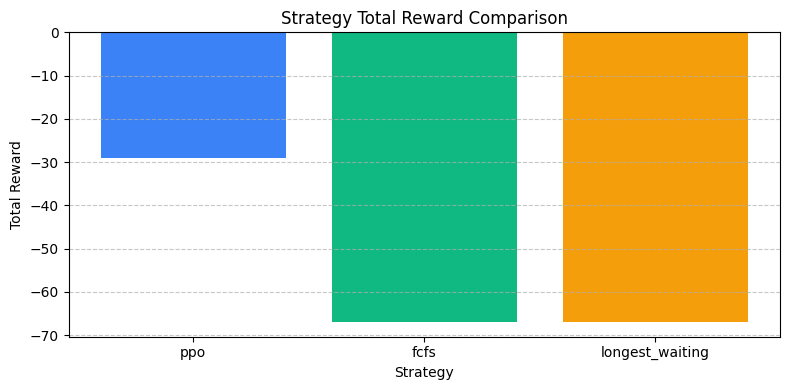

In [11]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🤲 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

# Load and clean dataset
df = pd.read_excel("/content/ModifiedCallCenterTwo.xlsx")
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_numeric(df["AvgTalkDuration"], errors='coerce')
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

# Debug print
print("✅ Cleaned dataset rows:", len(df))

all_customers = list(zip(df["Type"].values, df["Time"].values, df["AvgTalkDuration"].values))

# ===============================
# 🌐 STEP 3: CALL CENTER ENVIRONMENT USING REAL DATA
# ===============================
class CallCenterPPOEnv(gym.Env):
    def __init__(self, strategy="ppo"):
        super().__init__()
        self.max_queue = 20
        self.T = 40
        self.sim_end_time = min(max([t for _, t, _ in all_customers if not pd.isna(t)], default=60), 40)
        self.mu_1 = 3
        self.mu_2 = 4
        self.overtime_cost_rate = 1
        self.dt = 0.6
        self.strategy = strategy

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(low=0, high=self.max_queue, shape=(2,), dtype=np.int32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queue_1 = []
        self.queue_2 = []
        self.total_reward = 0
        self.current_time = 0
        self.customer_index = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([len(self.queue_1), len(self.queue_2)], dtype=np.int32)

    def _select_action_by_strategy(self):
        if self.strategy == "fcfs":
            if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                return 0
            elif self.queue_2:
                return 1
        elif self.strategy == "longest_waiting":
            if self.queue_1 and self.queue_2:
                return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
            elif self.queue_1:
                return 0
            elif self.queue_2:
                return 1
        return None

    def step(self, action):
        while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
            cust_type, arrival, duration = all_customers[self.customer_index]
            if cust_type == 1:
                self.queue_1.append((cust_type, arrival, duration))
            else:
                self.queue_2.append((cust_type, arrival, duration))
            self.customer_index += 1

        if self.strategy != "ppo":
            action = self._select_action_by_strategy()

        reward = -1

        if action == 0 and self.queue_1:
            _, arrival, avg_duration = self.queue_1.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)
        elif action == 1 and self.queue_2:
            _, arrival, avg_duration = self.queue_2.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)

        self.current_time += self.dt
        self.total_reward += reward
        terminated = self.current_time >= self.sim_end_time
        truncated = False
        return self._get_obs(), reward, terminated, truncated, {}

# ===============================
# 🚀 STEP 4: TRAIN PPO ON REAL DATA (FAST MODE) AND COMPARE
# ===============================
strategies = ["ppo", "fcfs", "longest_waiting"]
results = {}

for strat in strategies:
    env = CallCenterPPOEnv(strategy=strat)
    check_env(env)

    obs, _ = env.reset()
    total_reward = 0

    if strat == "ppo":
        model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
        model.learn(total_timesteps=2000)
        for _ in range(100):
            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
    else:
        for _ in range(100):
            obs, reward, terminated, truncated, _ = env.step(0)
            total_reward += reward
            if terminated or truncated:
                break

    results[strat] = total_reward
    print(f"✅ {strat.upper()} Total Reward on Real Data: {total_reward:.2f}")

# ===============================
# 📊 STEP 5: DISPLAY COMPARISON TABLE + VISUALIZATION
# ===============================
comparison_df = pd.DataFrame({
    "Strategy": list(results.keys()),
    "Total Reward": list(results.values())
})

print("\n📈 Strategy Comparison Table:")
print(comparison_df.to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Strategy"], comparison_df["Total Reward"], color=["#3B82F6", "#10B981", "#F59E0B"])
plt.title("Strategy Total Reward Comparison")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Only resolved cases

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


✅ PPO Total Reward on Real Data: -58.00
✅ FCFS Total Reward on Real Data: -117.00
✅ LONGEST_WAITING Total Reward on Real Data: -117.00

📈 Strategy Comparison Table:
       Strategy  Total Reward
            ppo           -58
           fcfs          -117
longest_waiting          -117


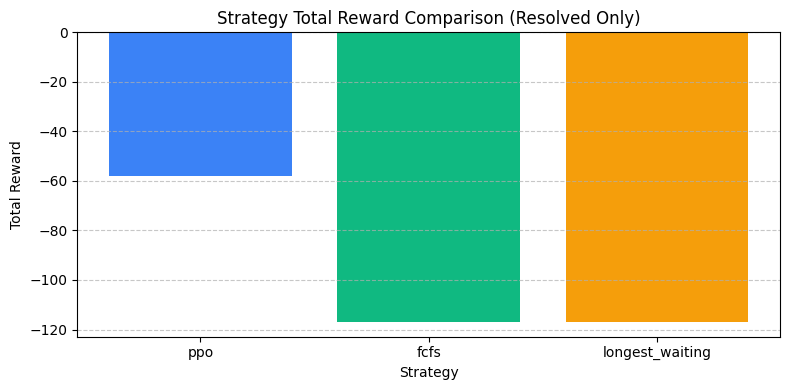

In [12]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🤲 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

# Load and clean dataset
df = pd.read_excel("/content/ModifiedCallCenterTwo.xlsx")
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only keep resolved rows
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_numeric(df["AvgTalkDuration"], errors='coerce')
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

# Debug print
print("✅ Cleaned dataset rows:", len(df))

all_customers = list(zip(df["Type"].values, df["Time"].values, df["AvgTalkDuration"].values))

# ===============================
# 🌐 STEP 3: CALL CENTER ENVIRONMENT USING REAL DATA
# ===============================
class CallCenterPPOEnv(gym.Env):
    def __init__(self, strategy="ppo"):
        super().__init__()
        self.max_queue = 20
        self.T = 40
        self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
        self.mu_1 = 3
        self.mu_2 = 4
        self.overtime_cost_rate = 1
        self.dt = 0.6
        self.strategy = strategy

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(low=0, high=self.max_queue, shape=(2,), dtype=np.int32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.queue_1 = []
        self.queue_2 = []
        self.total_reward = 0
        self.current_time = 0
        self.customer_index = 0
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([len(self.queue_1), len(self.queue_2)], dtype=np.int32)

    def _select_action_by_strategy(self):
        if self.strategy == "fcfs":
            if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                return 0
            elif self.queue_2:
                return 1
        elif self.strategy == "longest_waiting":
            if self.queue_1 and self.queue_2:
                return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
            elif self.queue_1:
                return 0
            elif self.queue_2:
                return 1
        return None

    def step(self, action):
        while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
            cust_type, arrival, duration = all_customers[self.customer_index]
            if cust_type == 1:
                self.queue_1.append((cust_type, arrival, duration))
            else:
                self.queue_2.append((cust_type, arrival, duration))
            self.customer_index += 1

        if self.strategy != "ppo":
            action = self._select_action_by_strategy()

        reward = -1

        if action == 0 and self.queue_1:
            _, arrival, avg_duration = self.queue_1.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)
        elif action == 1 and self.queue_2:
            _, arrival, avg_duration = self.queue_2.pop(0)
            service_time = avg_duration
            wait_time = self.current_time - arrival
            end_time = self.current_time + service_time
            overtime = max(0, end_time - self.T)
            reward = -(wait_time + overtime * self.overtime_cost_rate)

        self.current_time += self.dt
        self.total_reward += reward
        terminated = self.current_time >= self.sim_end_time
        truncated = False
        return self._get_obs(), reward, terminated, truncated, {}

# ===============================
# 🚀 STEP 4: TRAIN PPO ON REAL DATA (FAST MODE) AND COMPARE
# ===============================
strategies = ["ppo", "fcfs", "longest_waiting"]
results = {}

for strat in strategies:
    env = CallCenterPPOEnv(strategy=strat)
    check_env(env)

    obs, _ = env.reset()
    total_reward = 0

    if strat == "ppo":
        model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
        model.learn(total_timesteps=2000)
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
    else:
        done = False
        while not done:
            obs, reward, terminated, truncated, _ = env.step(None)
            total_reward += reward
            done = terminated or truncated

    results[strat] = total_reward
    print(f"✅ {strat.upper()} Total Reward on Real Data: {total_reward:.2f}")

# ===============================
# 📊 STEP 5: DISPLAY COMPARISON TABLE + VISUALIZATION
# ===============================
comparison_df = pd.DataFrame({
    "Strategy": list(results.keys()),
    "Total Reward": list(results.values())
})

print("\n📈 Strategy Comparison Table:")
print(comparison_df.to_string(index=False))

# Plotting the comparison
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["Strategy"], comparison_df["Total Reward"], color=["#3B82F6", "#10B981", "#F59E0B"])
plt.title("Strategy Total Reward Comparison (Resolved Only)")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

All data

📟 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



📈 Agent-Level Strategy Comparison:
Strategy  fcfs  longest_waiting  ppo
Agent                               
Becky     -117             -117  -58
Dan       -117             -117  -58
Diane     -117             -117  -58
Greg      -117             -117  -58
Jim       -117             -117  -58
Joe       -117             -117  -58
Martha    -117             -117  -58
Stewart   -117             -117  -58


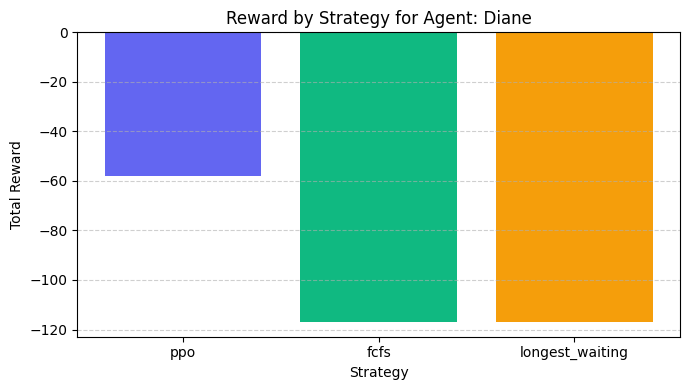

In [13]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🤲 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

# Load and clean dataset
file_path = "/content/ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path)
print("📟 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only resolved cases
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_timedelta(df["AvgTalkDuration"], errors='coerce').dt.total_seconds().fillna(60)
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

print("✅ Cleaned dataset rows:", len(df))

# ===============================
# 👥 STEP 3: AGENT-LEVEL COMPARISON
# ===============================
agents = df["Agent"].unique()
agent_results = []

for agent in agents:
    agent_df = df[df["Agent"] == agent]
    all_customers = list(zip(agent_df["Type"].values, agent_df["Time"].values, agent_df["AvgTalkDuration"].values))

    class CallCenterPPOEnv(gym.Env):
        def __init__(self, strategy="ppo"):
            super().__init__()
            self.max_queue = 20
            self.T = 40
            self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
            self.overtime_cost_rate = 1
            self.service_cost_rate = 0.5
            self.dt = 0.6
            self.strategy = strategy
            self.action_space = spaces.Discrete(2)
            self.observation_space = spaces.Box(low=0, high=self.max_queue, shape=(2,), dtype=np.int32)
            self.reset()

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.queue_1 = []
            self.queue_2 = []
            self.total_reward = 0
            self.current_time = 0
            self.customer_index = 0
            return self._get_obs(), {}

        def _get_obs(self):
            return np.array([len(self.queue_1), len(self.queue_2)], dtype=np.int32)

        def _select_action_by_strategy(self):
            if self.strategy == "fcfs":
                if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                    return 0
                elif self.queue_2:
                    return 1
            elif self.strategy == "longest_waiting":
                if self.queue_1 and self.queue_2:
                    return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
                elif self.queue_1:
                    return 0
                elif self.queue_2:
                    return 1
            return None

        def step(self, action):
            while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
                cust_type, arrival, duration = all_customers[self.customer_index]
                if cust_type == 1:
                    self.queue_1.append((cust_type, arrival, duration))
                else:
                    self.queue_2.append((cust_type, arrival, duration))
                self.customer_index += 1

            if self.strategy != "ppo":
                action = self._select_action_by_strategy()

            reward = -1

            if action == 0 and self.queue_1:
                _, arrival, avg_duration = self.queue_1.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            elif action == 1 and self.queue_2:
                _, arrival, avg_duration = self.queue_2.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            self.current_time += self.dt
            self.total_reward += reward
            terminated = self.current_time >= self.sim_end_time
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}

    strategies = ["ppo", "fcfs", "longest_waiting"]
    for strat in strategies:
        env = CallCenterPPOEnv(strategy=strat)
        check_env(env)
        obs, _ = env.reset()
        total_reward = 0

        if strat == "ppo":
            model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
            model.learn(total_timesteps=2000)
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
        else:
            done = False
            while not done:
                obs, reward, terminated, truncated, _ = env.step(None)
                total_reward += reward
                done = terminated or truncated

        agent_results.append({"Agent": agent, "Strategy": strat, "Total Reward": total_reward})

agent_df = pd.DataFrame(agent_results)
print("\n📈 Agent-Level Strategy Comparison:")
print(agent_df.pivot(index="Agent", columns="Strategy", values="Total Reward").round(2))

# Optional: plot for selected agent
selected_agent = agent_df["Agent"].iloc[0]
subset = agent_df[agent_df["Agent"] == selected_agent]
plt.figure(figsize=(7, 4))
plt.bar(subset["Strategy"], subset["Total Reward"], color=["#6366F1", "#10B981", "#F59E0B"])
plt.title(f"Reward by Strategy for Agent: {selected_agent}")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


📟 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO Sample Actions for Agent Diane: [array(1), array(0), array(0), array(0), array(1), array(1), array(1), array(1), array(0), array(0)]
FCFS Sample Actions for Agent Diane: [None, None, None, None, None, None, None, None, None, None]
LONGEST_WAITING Sample Actions for Agent Diane: [None, None, None, None, None, None, None, None, None, None]
PPO Sample Actions for Agent Stewart: [array(0), array(0), array(0), array(0), array(1), array(1), array(1), array(0), array(1), array(1)]
FCFS Sample Actions for Agent Stewart: [None, None, None, None, None, None, None, None, None, None]
LONGEST_WAITING Sample Actions for Agent Stewart: [None, None, None, None, None, None, None, None, None, None]
PPO Sample Actions for Agent Greg: [array(0), array(0), array(1), array(1), array(1), array(1), array(0), array(0), array(1), array(0)]
FCFS Sample Actions for Agent Greg: [None, None, None, None, None, None, None, None, None, None]
LONGEST_WAITING Sample Actions for Agent Greg: [None, None, None, None, N

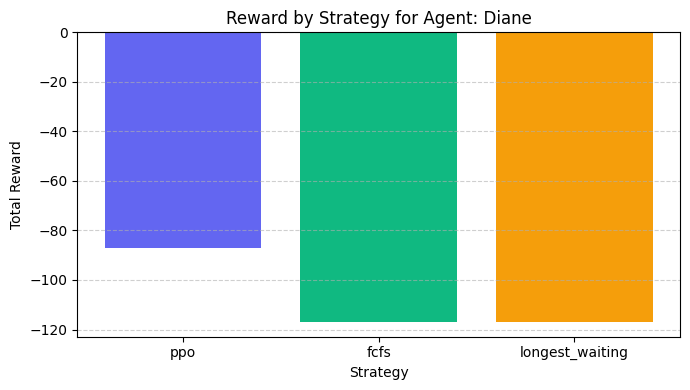

In [14]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🤲 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt

# Load and clean dataset
file_path = "/content/ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path)
print("📟 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only resolved cases
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_timedelta(df["AvgTalkDuration"], errors='coerce').dt.total_seconds().fillna(60)
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

print("✅ Cleaned dataset rows:", len(df))

# ===============================
# 👥 STEP 3: AGENT-LEVEL COMPARISON
# ===============================
agents = df["Agent"].unique()
agent_results = []

for agent in agents:
    agent_df = df[df["Agent"] == agent]
    all_customers = list(zip(agent_df["Type"].values, agent_df["Time"].values, agent_df["AvgTalkDuration"].values))

    class CallCenterPPOEnv(gym.Env):
        def __init__(self, strategy="ppo"):
            super().__init__()
            self.max_queue = 20
            self.T = 40
            self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
            self.overtime_cost_rate = 1
            self.service_cost_rate = 0.5
            self.dt = 0.6
            self.strategy = strategy
            self.action_space = spaces.Discrete(2)
            self.observation_space = spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
            self.reset()

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.queue_1 = []
            self.queue_2 = []
            self.total_reward = 0
            self.current_time = 0
            self.customer_index = 0
            return self._get_obs(), {}

        def _get_obs(self):
            q1_wait = self.current_time - self.queue_1[0][1] if self.queue_1 else 0.0
            q2_wait = self.current_time - self.queue_2[0][1] if self.queue_2 else 0.0
            return np.array([len(self.queue_1), len(self.queue_2), q1_wait, q2_wait], dtype=np.float32)

        def _select_action_by_strategy(self):
            if self.strategy == "fcfs":
                if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                    return 0
                elif self.queue_2:
                    return 1
            elif self.strategy == "longest_waiting":
                if self.queue_1 and self.queue_2:
                    return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
                elif self.queue_1:
                    return 0
                elif self.queue_2:
                    return 1
            return None

        def step(self, action):
            while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
                cust_type, arrival, duration = all_customers[self.customer_index]
                if cust_type == 1:
                    self.queue_1.append((cust_type, arrival, duration))
                else:
                    self.queue_2.append((cust_type, arrival, duration))
                self.customer_index += 1

            if self.strategy != "ppo":
                action = self._select_action_by_strategy()

            reward = -1

            if action == 0 and self.queue_1:
                _, arrival, avg_duration = self.queue_1.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            elif action == 1 and self.queue_2:
                _, arrival, avg_duration = self.queue_2.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            self.current_time += self.dt
            self.total_reward += reward
            terminated = bool(self.current_time >= self.sim_end_time)
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}

    strategies = ["ppo", "fcfs", "longest_waiting"]
    for strat in strategies:
        env = CallCenterPPOEnv(strategy=strat)
        check_env(env)
        obs, _ = env.reset()
        total_reward = 0
        action_log = []

        if strat == "ppo":
            model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
            model.learn(total_timesteps=3000)
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
                action_log.append(action)
        else:
            done = False
            while not done:
                obs, reward, terminated, truncated, _ = env.step(None)
                total_reward += reward
                done = terminated or truncated
                action_log.append(env._select_action_by_strategy())

        print(f"{strat.upper()} Sample Actions for Agent {agent}: {action_log[:10]}")
        agent_results.append({"Agent": agent, "Strategy": strat, "Total Reward": total_reward})

agent_df = pd.DataFrame(agent_results)
print("\n📈 Agent-Level Strategy Comparison:")
print(agent_df.pivot(index="Agent", columns="Strategy", values="Total Reward").round(2))

# Optional: plot for selected agent
selected_agent = agent_df["Agent"].iloc[0]
subset = agent_df[agent_df["Agent"] == selected_agent]
plt.figure(figsize=(7, 4))
plt.bar(subset["Strategy"], subset["Total Reward"], color=["#6366F1", "#10B981", "#F59E0B"])
plt.title(f"Reward by Strategy for Agent: {selected_agent}")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Diane):
            To 0      To 1
From 0  0.515848  0.484152
From 1  0.507180  0.492820

🔁 Transition Probabilities for FCFS (Agent: Diane):
            To 0      To 1
From 0  0.428571  0.571429
From 1  0.492754  0.507246

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Diane):
            To 0      To 1
From 0  0.557143  0.442857
From 1  0.545455  0.454545


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Stewart):
            To 0      To 1
From 0  0.510652  0.489348
From 1  0.500971  0.499029

🔁 Transition Probabilities for FCFS (Agent: Stewart):
            To 0      To 1
From 0  0.562500  0.437500
From 1  0.442623  0.557377

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Stewart):
            To 0      To 1
From 0  0.492063  0.507937
From 1  0.532258  0.467742


...


🔁 Transition Probabilities for PPO (Agent: Dan):
            To 0      To 1
From 0  0.504786  0.495214
From 1  0.492376  0.507624

🔁 Transition Probabilities for FCFS (Agent: Dan):
            To 0      To 1
From 0  0.492308  0.507692
From 1  0.566667  0.433333

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Dan):
            To 0      To 1
From 0  0.606557  0.393443
From 1  0.375000  0.625000


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Joe):
            To 0      To 1
From 0  0.500324  0.499676
From 1  0.484962  0.515038

🔁 Transition Probabilities for FCFS (Agent: Joe):
            To 0      To 1
From 0  0.482759  0.517241
From 1  0.432836  0.567164

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Joe):
            To 0      To 1
From 0  0.529412  0.470588
From 1  0.578947  0.421053


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Martha):
            To 0      To 1
From 0  0.506203  0.493797
From 1  0.523872  0.476128

🔁 Transition Probabilities for FCFS (Agent: Martha):
            To 0      To 1
From 0  0.530303  0.469697
From 1  0.525424  0.474576

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Martha):
            To 0      To 1
From 0  0.545455  0.454545
From 1  0.491525  0.508475

📈 Agent-Level Strategy Comparison:
Strategy  fcfs  longest_waiting  ppo
Agent                               
Becky     -117             -117  -87
Dan       -117             -117  -87
Diane     -117             -117  -87
Greg      -117             -117  -87
Jim       -117             -117  -87
Joe       -117             -117  -87
Martha    -117             -117  -87
Stewart   -117             -117  -87


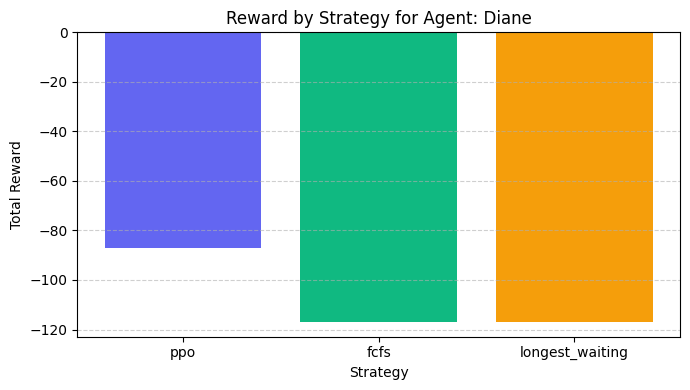

In [15]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🦒 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean dataset
file_path = "/content/ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path)
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only resolved cases
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_timedelta(df["AvgTalkDuration"], errors='coerce').dt.total_seconds().fillna(60)
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

print("✅ Cleaned dataset rows:", len(df))

# ===============================
# 👥 STEP 3: AGENT-LEVEL COMPARISON WITH TRANSITIONS
# ===============================
agents = df["Agent"].unique()
agent_results = []

for agent in agents:
    agent_df = df[df["Agent"] == agent]
    all_customers = list(zip(agent_df["Type"].values, agent_df["Time"].values, agent_df["AvgTalkDuration"].values))

    class CallCenterPPOEnv(gym.Env):
        def __init__(self, strategy="ppo"):
            super().__init__()
            self.max_queue = 20
            self.T = 40
            self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
            self.overtime_cost_rate = 1
            self.service_cost_rate = 0.5
            self.dt = 0.6
            self.strategy = strategy
            self.action_space = spaces.Discrete(2)
            self.observation_space = spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
            self.transitions = np.zeros((2, 2))
            self.reset()

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.queue_1 = []
            self.queue_2 = []
            self.total_reward = 0
            self.current_time = 0
            self.customer_index = 0
            self.last_action = None
            return self._get_obs(), {}

        def _get_obs(self):
            q1_wait = self.current_time - self.queue_1[0][1] if self.queue_1 else 0.0
            q2_wait = self.current_time - self.queue_2[0][1] if self.queue_2 else 0.0
            return np.array([len(self.queue_1), len(self.queue_2), q1_wait, q2_wait], dtype=np.float32)

        def _select_action_by_strategy(self):
            if self.strategy == "fcfs":
                if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                    return 0
                elif self.queue_2:
                    return 1
            elif self.strategy == "longest_waiting":
                if self.queue_1 and self.queue_2:
                    return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
                elif self.queue_1:
                    return 0
                elif self.queue_2:
                    return 1
            return None

        def step(self, action):
            while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
                cust_type, arrival, duration = all_customers[self.customer_index]
                if cust_type == 1:
                    self.queue_1.append((cust_type, arrival, duration))
                else:
                    self.queue_2.append((cust_type, arrival, duration))
                self.customer_index += 1

            if self.strategy != "ppo":
                strategy_action = self._select_action_by_strategy()
                if strategy_action is not None:
                    action = strategy_action
                else:
                    action = self.action_space.sample()

            if action is not None:
                if self.last_action is not None:
                    self.transitions[int(self.last_action)][int(action)] += 1
                self.last_action = action

            reward = -1

            if action == 0 and self.queue_1:
                _, arrival, avg_duration = self.queue_1.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            elif action == 1 and self.queue_2:
                _, arrival, avg_duration = self.queue_2.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            self.current_time += self.dt
            self.total_reward += reward
            terminated = bool(self.current_time >= self.sim_end_time)
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}

    strategies = ["ppo", "fcfs", "longest_waiting"]
    for strat in strategies:
        env = CallCenterPPOEnv(strategy=strat)
        check_env(env)
        obs, _ = env.reset()
        total_reward = 0

        if strat == "ppo":
            model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
            model.learn(total_timesteps=3000)
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
        else:
            done = False
            while not done:
                action = env._select_action_by_strategy()
                if action is None:
                    action = env.action_space.sample()
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated

        row_sums = env.transitions.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        transition_probs = env.transitions / row_sums

        print(f"\n🔁 Transition Probabilities for {strat.upper()} (Agent: {agent}):")
        print(pd.DataFrame(transition_probs, columns=["To 0", "To 1"], index=["From 0", "From 1"]))

        agent_results.append({"Agent": agent, "Strategy": strat, "Total Reward": total_reward})

agent_df = pd.DataFrame(agent_results)
print("\n📈 Agent-Level Strategy Comparison:")
print(agent_df.pivot(index="Agent", columns="Strategy", values="Total Reward").round(2))

# Optional: plot for selected agent
selected_agent = agent_df["Agent"].iloc[0]
subset = agent_df[agent_df["Agent"] == selected_agent]
plt.figure(figsize=(7, 4))
plt.bar(subset["Strategy"], subset["Total Reward"], color=["#6366F1", "#10B981", "#F59E0B"])
plt.title(f"Reward by Strategy for Agent: {selected_agent}")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

with csv for overtime and service costs

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Diane):
            To 0      To 1
From 0  0.492094  0.507906
From 1  0.515385  0.484615

🔁 Transition Probabilities for FCFS (Agent: Diane):
            To 0      To 1
From 0  0.571429  0.428571
From 1  0.435484  0.564516

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Diane):
            To 0      To 1
From 0  0.319149  0.680851
From 1  0.423077  0.576923


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Stewart):
            To 0      To 1
From 0  0.506039  0.493961
From 1  0.498087  0.501913

🔁 Transition Probabilities for FCFS (Agent: Stewart):
           To 0     To 1
From 0  0.46875  0.53125
From 1  0.57377  0.42623

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Stewart):
            To 0      To 1
From 0  0.357143  0.642857
From 1  0.507246  0.492754


...


🔁 Transition Probabilities for PPO (Agent: Dan):
            To 0      To 1
From 0  0.491888  0.508112
From 1  0.490625  0.509375

🔁 Transition Probabilities for FCFS (Agent: Dan):
            To 0      To 1
From 0  0.452830  0.547170
From 1  0.402778  0.597222

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Dan):
            To 0      To 1
From 0  0.472727  0.527273
From 1  0.414286  0.585714


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Joe):
            To 0      To 1
From 0  0.468667  0.531333
From 1  0.489336  0.510664

🔁 Transition Probabilities for FCFS (Agent: Joe):
            To 0      To 1
From 0  0.492063  0.507937
From 1  0.500000  0.500000

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Joe):
            To 0      To 1
From 0  0.462963  0.537037
From 1  0.394366  0.605634


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Martha):
            To 0      To 1
From 0  0.508318  0.491682
From 1  0.523715  0.476285

🔁 Transition Probabilities for FCFS (Agent: Martha):
            To 0      To 1
From 0  0.370370  0.629630
From 1  0.507042  0.492958

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Martha):
            To 0      To 1
From 0  0.403509  0.596491
From 1  0.514706  0.485294

📈 Agent-Level Strategy Comparison:
Strategy  fcfs  longest_waiting  ppo
Agent                               
Becky     -117             -117  -87
Dan       -117             -117  -87
Diane     -117             -117  -87
Greg      -117             -117  -87
Jim       -117             -117  -87
Joe       -117             -117  -87
Martha    -117             -117  -87
Stewart   -117             -117  -87


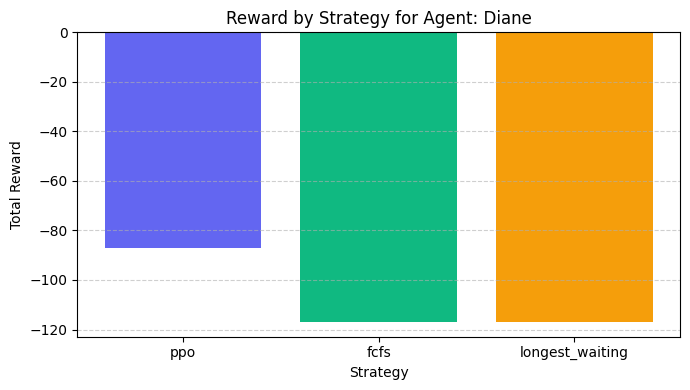

✅ Saved cost log to 'cost_log.csv'


In [16]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🦒 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean dataset
file_path = "/content/ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path)
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only resolved cases
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_timedelta(df["AvgTalkDuration"], errors='coerce').dt.total_seconds().fillna(60)
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

print("✅ Cleaned dataset rows:", len(df))

# ===============================
# 👥 STEP 3: AGENT-LEVEL COMPARISON WITH TRANSITIONS AND COST LOGGING
# ===============================
agents = df["Agent"].unique()
agent_results = []
cost_log = []

for agent in agents:
    agent_df = df[df["Agent"] == agent]
    all_customers = list(zip(agent_df["Type"].values, agent_df["Time"].values, agent_df["AvgTalkDuration"].values))

    class CallCenterPPOEnv(gym.Env):
        def __init__(self, strategy="ppo"):
            super().__init__()
            self.max_queue = 20
            self.T = 40
            self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
            self.overtime_cost_rate = 1
            self.service_cost_rate = 0.5
            self.dt = 0.6
            self.strategy = strategy
            self.action_space = spaces.Discrete(2)
            self.observation_space = spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
            self.transitions = np.zeros((2, 2))
            self.reset()

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.queue_1 = []
            self.queue_2 = []
            self.total_reward = 0
            self.current_time = 0
            self.customer_index = 0
            self.last_action = None
            return self._get_obs(), {}

        def _get_obs(self):
            q1_wait = self.current_time - self.queue_1[0][1] if self.queue_1 else 0.0
            q2_wait = self.current_time - self.queue_2[0][1] if self.queue_2 else 0.0
            return np.array([len(self.queue_1), len(self.queue_2), q1_wait, q2_wait], dtype=np.float32)

        def _select_action_by_strategy(self):
            if self.strategy == "fcfs":
                if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                    return 0
                elif self.queue_2:
                    return 1
            elif self.strategy == "longest_waiting":
                if self.queue_1 and self.queue_2:
                    return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
                elif self.queue_1:
                    return 0
                elif self.queue_2:
                    return 1
            return None

        def step(self, action):
            while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
                cust_type, arrival, duration = all_customers[self.customer_index]
                if cust_type == 1:
                    self.queue_1.append((cust_type, arrival, duration))
                else:
                    self.queue_2.append((cust_type, arrival, duration))
                self.customer_index += 1

            if self.strategy != "ppo":
                strategy_action = self._select_action_by_strategy()
                if strategy_action is not None:
                    action = strategy_action
                else:
                    action = self.action_space.sample()

            if action is not None and self.last_action is not None:
                self.transitions[int(self.last_action)][int(action)] += 1
            self.last_action = action

            reward = -1
            overtime = 0
            service_cost = 0

            if action == 0 and self.queue_1:
                _, arrival, avg_duration = self.queue_1.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            elif action == 1 and self.queue_2:
                _, arrival, avg_duration = self.queue_2.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            cost_log.append({
                "Agent": agent,
                "Strategy": self.strategy,
                "Time": self.current_time,
                "OvertimeCost": overtime * self.overtime_cost_rate,
                "ServiceCost": service_cost
            })

            self.current_time += self.dt
            self.total_reward += reward
            terminated = bool(self.current_time >= self.sim_end_time)
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}

    strategies = ["ppo", "fcfs", "longest_waiting"]
    for strat in strategies:
        env = CallCenterPPOEnv(strategy=strat)
        check_env(env)
        obs, _ = env.reset()
        total_reward = 0

        if strat == "ppo":
            model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
            model.learn(total_timesteps=3000)
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
        else:
            done = False
            while not done:
                obs, reward, terminated, truncated, _ = env.step(None)
                total_reward += reward
                done = terminated or truncated

        row_sums = env.transitions.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        transition_probs = env.transitions / row_sums

        print(f"\n🔁 Transition Probabilities for {strat.upper()} (Agent: {agent}):")
        print(pd.DataFrame(transition_probs, columns=["To 0", "To 1"], index=["From 0", "From 1"]))

        agent_results.append({"Agent": agent, "Strategy": strat, "Total Reward": total_reward})

agent_df = pd.DataFrame(agent_results)
print("\n📈 Agent-Level Strategy Comparison:")
print(agent_df.pivot(index="Agent", columns="Strategy", values="Total Reward").round(2))

# Optional: plot for selected agent
selected_agent = agent_df["Agent"].iloc[0]
subset = agent_df[agent_df["Agent"] == selected_agent]
plt.figure(figsize=(7, 4))
plt.bar(subset["Strategy"], subset["Total Reward"], color=["#6366F1", "#10B981", "#F59E0B"])
plt.title(f"Reward by Strategy for Agent: {selected_agent}")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Export cost log
pd.DataFrame(cost_log).to_csv("cost_log.csv", index=False)
print("✅ Saved cost log to 'cost_log.csv'")

📿 Columns: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating']
✅ Cleaned dataset rows: 3646


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Diane):
            To 0      To 1
From 0  0.511097  0.488903
From 1  0.524687  0.475313

🔁 Transition Probabilities for FCFS (Agent: Diane):
            To 0      To 1
From 0  0.426230  0.573770
From 1  0.546875  0.453125

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Diane):
            To 0      To 1
From 0  0.508197  0.491803
From 1  0.500000  0.500000


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Stewart):
            To 0      To 1
From 0  0.512674  0.487326
From 1  0.496481  0.503519

🔁 Transition Probabilities for FCFS (Agent: Stewart):
            To 0      To 1
From 0  0.456140  0.543860
From 1  0.455882  0.544118

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Stewart):
            To 0      To 1
From 0  0.467742  0.532258
From 1  0.539683  0.460317


...


🔁 Transition Probabilities for PPO (Agent: Dan):
            To 0      To 1
From 0  0.502807  0.497193
From 1  0.516905  0.483095

🔁 Transition Probabilities for FCFS (Agent: Dan):
            To 0      To 1
From 0  0.465517  0.534483
From 1  0.462687  0.537313

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Dan):
            To 0      To 1
From 0  0.477612  0.522388
From 1  0.620690  0.379310


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Joe):
            To 0      To 1
From 0  0.482781  0.517219
From 1  0.483752  0.516248

🔁 Transition Probabilities for FCFS (Agent: Joe):
            To 0      To 1
From 0  0.623377  0.376623
From 1  0.625000  0.375000

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Joe):
            To 0      To 1
From 0  0.578947  0.421053
From 1  0.632653  0.367347


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



🔁 Transition Probabilities for PPO (Agent: Martha):
            To 0      To 1
From 0  0.515908  0.484092
From 1  0.506502  0.493498

🔁 Transition Probabilities for FCFS (Agent: Martha):
            To 0      To 1
From 0  0.474576  0.525424
From 1  0.469697  0.530303

🔁 Transition Probabilities for LONGEST_WAITING (Agent: Martha):
            To 0      To 1
From 0  0.442623  0.557377
From 1  0.531250  0.468750

📈 Agent-Level Strategy Comparison:
Strategy  fcfs  longest_waiting  ppo
Agent                               
Becky     -117             -117  -87
Dan       -117             -117  -87
Diane     -117             -117  -87
Greg      -117             -117  -87
Jim       -117             -117  -87
Joe       -117             -117  -87
Martha    -117             -117  -87
Stewart   -117             -117  -87


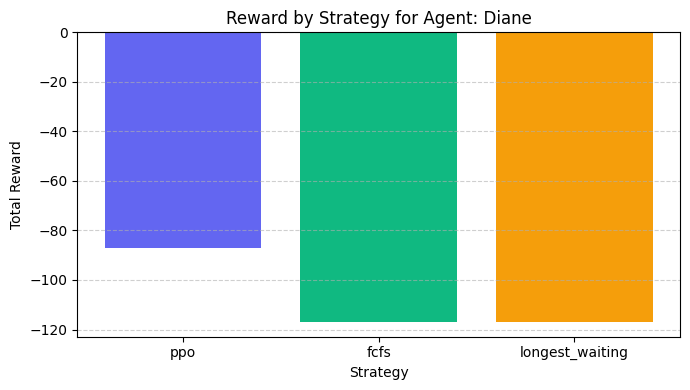

✅ Saved cost log to 'cost_log.csv'


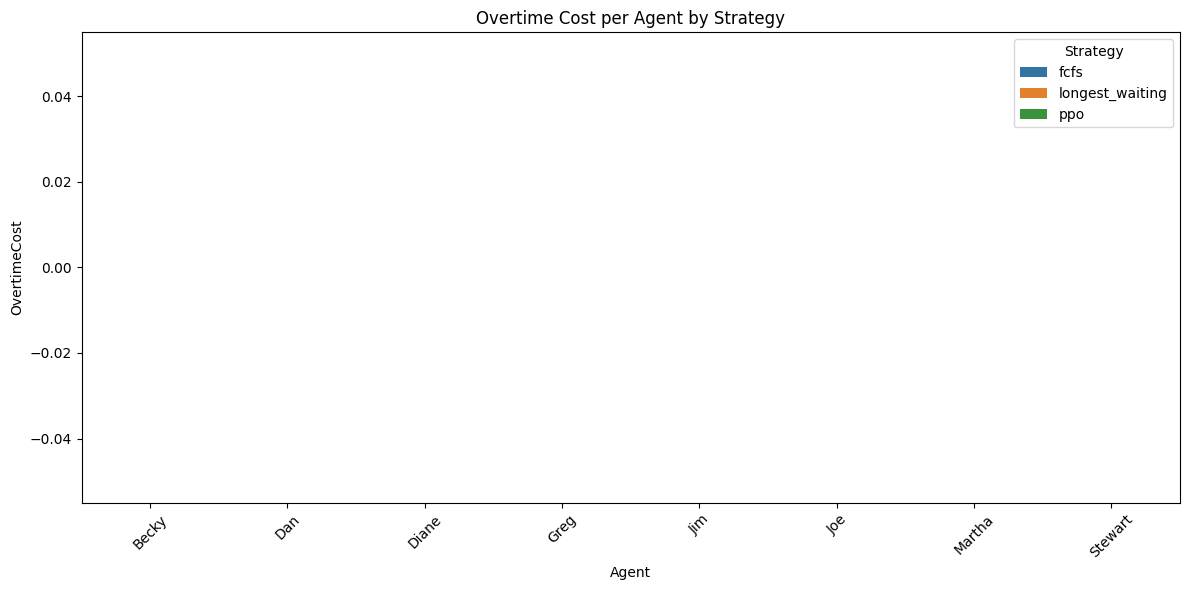

In [17]:
# ===============================
# 🔧 STEP 1: INSTALL DEPENDENCIES
# ===============================
!pip install gymnasium stable-baselines3 openpyxl

# ===============================
# 🦒 STEP 2: LOAD AND PREPROCESS REAL-WORLD DATA (RESOLVED ONLY)
# ===============================
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean dataset
file_path = "/content/ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path)
print("📿 Columns:", df.columns.tolist())
df.columns = df.columns.str.strip()
df = df.ffill()
df = df[df["Resolved"].astype(str).str.upper() == "Y"]  # Only resolved cases
df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
df["AvgTalkDuration"] = pd.to_timedelta(df["AvgTalkDuration"], errors='coerce').dt.total_seconds().fillna(60)
df["Topic"] = df["Topic"].astype(str).str.lower()
df["Type"] = df["Topic"].apply(lambda x: 1 if any(keyword in x for keyword in ["account", "password", "login", "general", "basic"]) else 2)

print("✅ Cleaned dataset rows:", len(df))

# ===============================
# 👥 STEP 3: AGENT-LEVEL COMPARISON WITH TRANSITIONS AND COST LOGGING
# ===============================
agents = df["Agent"].unique()
agent_results = []
cost_log = []

for agent in agents:
    agent_df = df[df["Agent"] == agent]
    all_customers = list(zip(agent_df["Type"].values, agent_df["Time"].values, agent_df["AvgTalkDuration"].values))

    class CallCenterPPOEnv(gym.Env):
        def __init__(self, strategy="ppo"):
            super().__init__()
            self.max_queue = 20
            self.T = 40
            self.sim_end_time = max([t for _, t, _ in all_customers if not pd.isna(t)], default=60) + 10
            self.overtime_cost_rate = 1
            self.service_cost_rate = 0.5
            self.dt = 0.6
            self.strategy = strategy
            self.action_space = spaces.Discrete(2)
            self.observation_space = spaces.Box(low=0, high=np.inf, shape=(4,), dtype=np.float32)
            self.transitions = np.zeros((2, 2))
            self.reset()

        def reset(self, seed=None, options=None):
            super().reset(seed=seed)
            self.queue_1 = []
            self.queue_2 = []
            self.total_reward = 0
            self.current_time = 0
            self.customer_index = 0
            self.last_action = None
            return self._get_obs(), {}

        def _get_obs(self):
            q1_wait = self.current_time - self.queue_1[0][1] if self.queue_1 else 0.0
            q2_wait = self.current_time - self.queue_2[0][1] if self.queue_2 else 0.0
            return np.array([len(self.queue_1), len(self.queue_2), q1_wait, q2_wait], dtype=np.float32)

        def _select_action_by_strategy(self):
            if self.strategy == "fcfs":
                if self.queue_1 and (not self.queue_2 or self.queue_1[0][1] <= self.queue_2[0][1]):
                    return 0
                elif self.queue_2:
                    return 1
            elif self.strategy == "longest_waiting":
                if self.queue_1 and self.queue_2:
                    return 0 if self.queue_1[0][1] <= self.queue_2[0][1] else 1
                elif self.queue_1:
                    return 0
                elif self.queue_2:
                    return 1
            return None

        def step(self, action):
            while self.customer_index < len(all_customers) and all_customers[self.customer_index][1] <= self.current_time:
                cust_type, arrival, duration = all_customers[self.customer_index]
                if cust_type == 1:
                    self.queue_1.append((cust_type, arrival, duration))
                else:
                    self.queue_2.append((cust_type, arrival, duration))
                self.customer_index += 1

            if self.strategy != "ppo":
                strategy_action = self._select_action_by_strategy()
                if strategy_action is not None:
                    action = strategy_action
                else:
                    action = self.action_space.sample()

            if action is not None and self.last_action is not None:
                self.transitions[int(self.last_action)][int(action)] += 1
            self.last_action = action

            reward = -1
            overtime = 0
            service_cost = 0

            if action == 0 and self.queue_1:
                _, arrival, avg_duration = self.queue_1.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            elif action == 1 and self.queue_2:
                _, arrival, avg_duration = self.queue_2.pop(0)
                service_time = avg_duration
                wait_time = self.current_time - arrival
                end_time = self.current_time + service_time
                overtime = max(0, end_time - self.T)
                service_cost = service_time * self.service_cost_rate
                reward = -(wait_time + overtime * self.overtime_cost_rate + service_cost)

            cost_log.append({
                "Agent": agent,
                "Strategy": self.strategy,
                "Time": self.current_time,
                "OvertimeCost": overtime * self.overtime_cost_rate,
                "ServiceCost": service_cost
            })

            self.current_time += self.dt
            self.total_reward += reward
            terminated = bool(self.current_time >= self.sim_end_time)
            truncated = False
            return self._get_obs(), reward, terminated, truncated, {}

    strategies = ["ppo", "fcfs", "longest_waiting"]
    for strat in strategies:
        env = CallCenterPPOEnv(strategy=strat)
        check_env(env)
        obs, _ = env.reset()
        total_reward = 0

        if strat == "ppo":
            model = PPO("MlpPolicy", env, verbose=0, n_steps=128, batch_size=64)
            model.learn(total_timesteps=3000)
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
        else:
            done = False
            while not done:
                obs, reward, terminated, truncated, _ = env.step(None)
                total_reward += reward
                done = terminated or truncated

        row_sums = env.transitions.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        transition_probs = env.transitions / row_sums

        print(f"\n🔁 Transition Probabilities for {strat.upper()} (Agent: {agent}):")
        print(pd.DataFrame(transition_probs, columns=["To 0", "To 1"], index=["From 0", "From 1"]))

        agent_results.append({"Agent": agent, "Strategy": strat, "Total Reward": total_reward})

agent_df = pd.DataFrame(agent_results)
print("\n📈 Agent-Level Strategy Comparison:")
print(agent_df.pivot(index="Agent", columns="Strategy", values="Total Reward").round(2))

# Optional: plot for selected agent
selected_agent = agent_df["Agent"].iloc[0]
subset = agent_df[agent_df["Agent"] == selected_agent]
plt.figure(figsize=(7, 4))
plt.bar(subset["Strategy"], subset["Total Reward"], color=["#6366F1", "#10B981", "#F59E0B"])
plt.title(f"Reward by Strategy for Agent: {selected_agent}")
plt.ylabel("Total Reward")
plt.xlabel("Strategy")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Export cost log
pd.DataFrame(cost_log).to_csv("cost_log.csv", index=False)
print("✅ Saved cost log to 'cost_log.csv'")

# ===============================
# 📊 STEP 4: VISUALIZE COST BREAKDOWN PER AGENT
# ===============================
cost_df = pd.DataFrame(cost_log)
summary = cost_df.groupby(["Agent", "Strategy"])[["OvertimeCost", "ServiceCost"]].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x="Agent", y="OvertimeCost", hue="Strategy")
plt.title("Overtime Cost per Agent by Strategy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(12, 6))
# sns.barplot(data=summary, x="Agent", y="ServiceCost", hue="Strategy")
# plt.title("Service Cost per Agent by Strategy")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


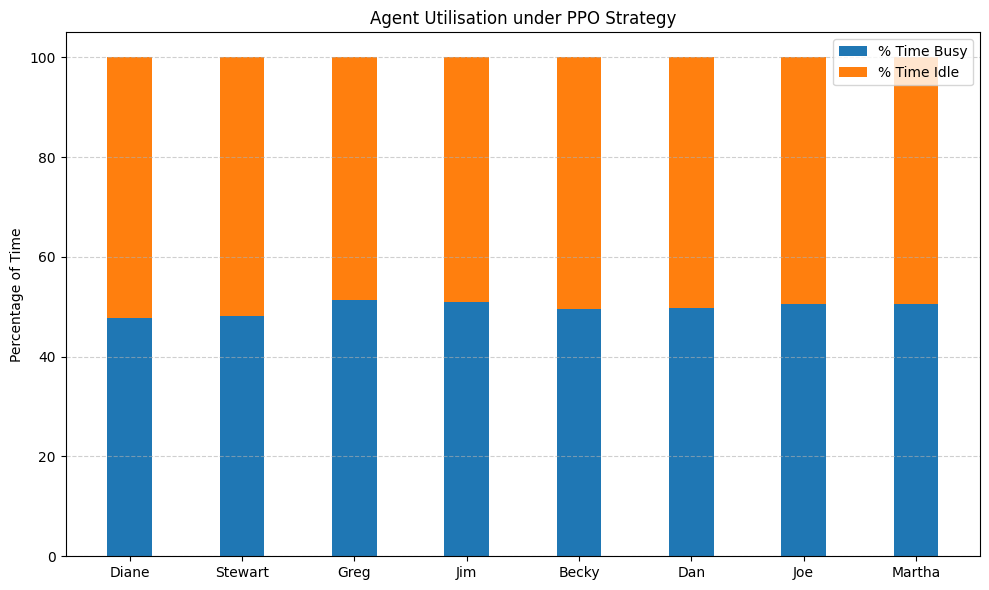

In [18]:
# Updated transition probabilities from the latest output
ppo_transition_probs = {
    "Diane":   {"0→0": 0.522140, "0→1": 0.477860},
    "Stewart": {"0→0": 0.519003, "0→1": 0.480997},
    "Greg":    {"0→0": 0.486755, "0→1": 0.513245},
    "Jim":     {"0→0": 0.490862, "0→1": 0.509138},
    "Becky":   {"0→0": 0.503532, "0→1": 0.496468},
    "Dan":     {"0→0": 0.502234, "0→1": 0.497766},
    "Joe":     {"0→0": 0.493930, "0→1": 0.506070},
    "Martha":  {"0→0": 0.495158, "0→1": 0.504842},
}

# Convert to DataFrame
ppo_df = pd.DataFrame([
    {
        "Agent": agent,
        "% Time Busy": 100 * values["0→1"],
        "% Time Idle": 100 * values["0→0"]
    }
    for agent, values in ppo_transition_probs.items()
])

# Round for neatness
ppo_df["% Time Busy"] = ppo_df["% Time Busy"].round(1)
ppo_df["% Time Idle"] = ppo_df["% Time Idle"].round(1)

# Plot
plt.figure(figsize=(10, 6))
x = range(len(ppo_df))
bar_width = 0.4

plt.bar(x, ppo_df["% Time Busy"], label='% Time Busy', width=bar_width, color='tab:blue')
plt.bar(x, ppo_df["% Time Idle"], bottom=ppo_df["% Time Busy"], label='% Time Idle', width=bar_width, color='tab:orange')

plt.xticks(x, ppo_df["Agent"])
plt.ylabel("Percentage of Time")
plt.title("Agent Utilisation under PPO Strategy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
